# SIT720 8.1D : Sydney Housing Price Prediction & Decision Support System

Full ML lifecycle for a Sydney housing-price prediction problem, framed as a real-estate decision-support tool. Organised to the six parts of the brief.

| Part | Focus |
|------|-------|
| 1 | Problem definition & data collection |
| 2 | Data understanding & feature engineering |
| 3 | Model development & evaluation (3 models, k-fold CV) |
| 4 | Investigating prediction failures (5 largest errors) |
| 5 | Human vs ML vs LLM on the 10 held-out properties |
| 6 | Deployment (Streamlit app) & reflection |


Data: `sydney_housing.csv` : 102 sold properties across Mosman, Blacktown and Parramatta (Jun–Sep 2026)


In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path("model"); MODEL_DIR.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")

Setup complete.


## Part 1 : Problem Definition & Data Collection

The problem. A real-estate agency wants a tool that estimates a Sydney property's likely sale price from its characteristics, to support an agent's appraisal rather than replace it. Target: `sale_price` (AUD). Inputs: property features from public sold listings.

Suburbs (chosen for contrasting markets):
- **Mosman** : blue-chip lower-north-shore; high median, wide spread (harbourside premiums).
- **Parramatta** : dense, apartment-heavy metropolitan centre; mid-market.
- **Blacktown** : more affordable outer-west; house-and-land mix.

I chose these suburbs to compare different buying options. Blacktown represents a more affordable option in my sample, which would appeal to me if keeping the purchase cost manageable was the main priority. Parramatta offers an apartment-focused alternative that I would consider if I preferred a smaller property over a house. Mosman represents the higher-budget option, with a much wider price range and several expensive houses. I would consider it if my budget allowed a more premium property. Together, these suburbs let me investigate how location and property characteristics affect prices across different markets.

Data was transcribed from public Domain.com.au sold listings. The dataset contains 102 properties individually transcribed from publicly available Domain sold listings. The recorded information included address, suburb, advertised sale price, sale date, property type, bedrooms, bathrooms and car spaces. Unavailable values were left missing rather than guessed. 


In [2]:
DATA_PATH = Path("sydney_housing.csv")
assert DATA_PATH.exists(), "sydney_housing.csv not found — place it beside this notebook."
df = pd.read_csv(DATA_PATH, parse_dates=["sale_date"])
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 102 rows, 10 columns


,property_id,address,suburb,property_type,bedrooms,bathrooms,car_spaces,sale_date,sale_price,split
0,SYD001,25/8-10 Fourth Avenue,Blacktown,Apartment,2,1,1.00,2026-09-16,415000,development
1,SYD002,17 st pauls way,Blacktown,Townhouse,3,2,1.00,2026-09-15,828000,development
2,SYD003,3/130 Newton Road,Blacktown,Townhouse,2,1,1.00,2026-09-14,700000,development
3,SYD004,4 &4 A Joseph Street,Blacktown,House,5,2,5.00,2026-09-14,1340000,development
4,SYD005,3/28 Frederick Street,Blacktown,Townhouse,2,1,1.00,2026-09-14,732500,development


In [3]:
print("Rows per suburb (need >=30 each):")
print(df["suburb"].value_counts(), "\n")
print("Split:", df["split"].value_counts().to_dict(), "\n")
print("Missing values:")
print(df.isna().sum(), "\n")
print(df[["bedrooms","bathrooms","car_spaces","sale_price"]].describe().T)

Rows per suburb (need >=30 each):
suburb
Mosman        35
Blacktown     34
Parramatta    33
Name: count, dtype: int64 

Split: {'development': 92, 'holdout': 10} 

Missing values:
property_id       0
address           0
suburb            0
property_type     0
bedrooms          0
bathrooms         0
car_spaces       11
sale_date         0
sale_price        0
split             0
dtype: int64 

            count         mean          std        min        25%        50%  \
bedrooms   102.00         2.46         1.32       0.00       2.00       2.00   
bathrooms  102.00         1.62         0.80       1.00       1.00       1.00   
car_spaces  91.00         1.49         1.14       1.00       1.00       1.00   
sale_price 102.00 1,478,406.86 1,925,538.61 250,000.00 561,500.00 802,500.00   

                    75%           max  
bedrooms           3.00          7.00  
bathrooms          2.00          4.00  
car_spaces         1.00          6.00  
sale_price 1,415,000.00 11,650,000.00  


Note on dropped fields: Land size and advertised floor area were published for only ~17% and ~30% of listings respectively, and build year was almost never shown, so those columns were dropped rather than imputed from near-nothing. Where present, the area figures were advertised rather than independently verified. Two singleton categories (Studio, Semi-detached) were folded into their nearest type (Apartment, House). The honest consequence: the model leans on bedrooms, bathrooms, car spaces, suburb and property type — a deliberately lean feature set.

## Part 2 : Data Understanding & Feature Engineering

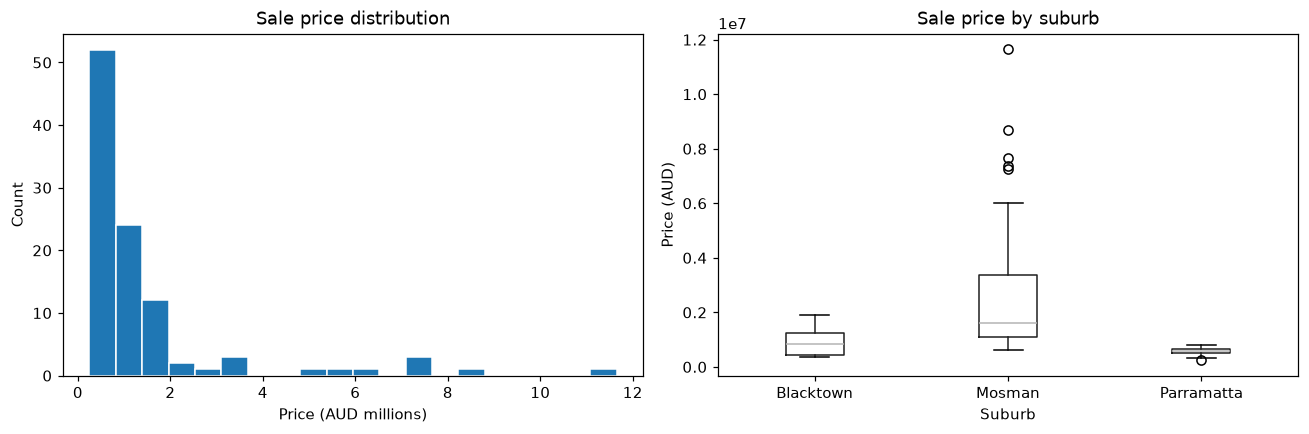

            count       median       max
suburb                                  
Blacktown      34   854,000.00   1900000
Mosman         35 1,600,000.00  11650000
Parramatta     33   580,000.00    800000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(df["sale_price"]/1e6, bins=20, edgecolor="white")
axes[0].set(title="Sale price distribution", xlabel="Price (AUD millions)", ylabel="Count")
df.boxplot(column="sale_price", by="suburb", ax=axes[1], grid=False)
axes[1].set(title="Sale price by suburb", xlabel="Suburb", ylabel="Price (AUD)")
plt.suptitle(""); fig.tight_layout()
fig.savefig(FIG_DIR / "price_distribution.png", bbox_inches="tight")
plt.show()
print(df.groupby("suburb")["sale_price"].agg(["count","median","max"]))

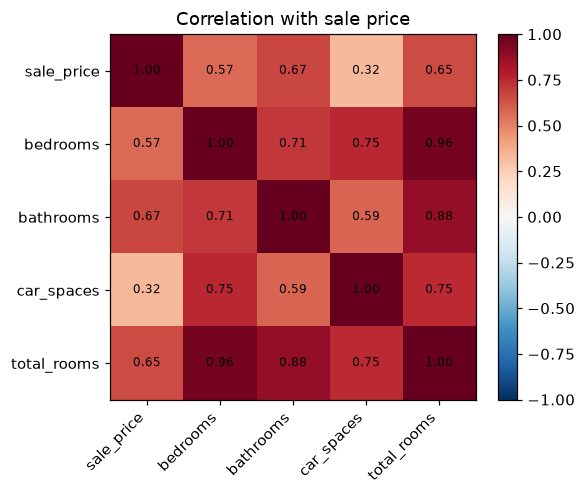

sale_price    1.00
bathrooms     0.67
total_rooms   0.65
bedrooms      0.57
car_spaces    0.32
Name: sale_price, dtype: float64


In [5]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]   
num = ["sale_price","bedrooms","bathrooms","car_spaces","total_rooms"]
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num))); ax.set_xticklabels(num, rotation=45, ha="right")
ax.set_yticks(range(len(num))); ax.set_yticklabels(num)
for (i,j),v in np.ndenumerate(corr.values): ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8)
ax.set_title("Correlation with sale price"); fig.colorbar(im, fraction=0.046)
fig.tight_layout(); fig.savefig(FIG_DIR / "correlations.png", bbox_inches="tight"); plt.show()
print(corr["sale_price"].sort_values(ascending=False))

Before modelling, I expected suburb, bedrooms and bathrooms to have the greatest influence on sale price. Suburb seemed important because location can affect what buyers are willing to pay, and the sample medians differed considerably: $1.60 million in Mosman, $854,000 in Blacktown and $580,000 in Parramatta.

I expected bedrooms to matter because they indicate accommodation capacity, while bathrooms may reflect a property's size and convenience. The exploratory results supported these expectations: bedrooms had a correlation of 0.57 with sale price, and bathrooms had a stronger correlation of 0.67. However, these relationships do not prove which features the models will rely on most. After training, I would compare this expectation with model-based feature importance.

Note the very narrow sale window (Jun–Sep 2026): there's essentially no time trend to exploit, so `sale_date` is used for description only, not as a model feature — worth stating as a limitation.

## Part 3 : Model Development & Evaluation

Three models from different families; cross-validation is run on the `development` rows only (the 10 `holdout` rows are reserved for Part 5).

| Model | Family | Rationale |
|-------|--------|-----------|
| **Ridge** | Linear (regularised) | Interpretable baseline; assumes additive, near-linear effects |
| **Random Forest** | Bagging ensemble | Captures non-linearity & interactions; robust to outliers |
| **Gradient Boosting** | Boosting ensemble | Often strongest on tabular data; fits residuals sequentially |

Before training, I expected Random Forest to perform best. Property prices may depend on combinations of features. for example, an extra bedroom could add different amounts of value in different suburbs. Random Forest can capture these interactions and non-linear relationships. Averaging many trees may also help it generalise better than Gradient Boosting on this small dataset. I expected Ridge Regression to provide a useful baseline, but its linear structure might struggle with the wide price differences. I would check this prediction using the five-fold cross-validation results.

In [6]:
dev = df[df["split"] == "development"].copy()
holdout = df[df["split"] == "holdout"].copy()

NUMERIC = ["bedrooms", "bathrooms", "car_spaces", "total_rooms"]
CATEGORICAL = ["suburb", "property_type"]
FEATURES = NUMERIC + CATEGORICAL
TARGET = "sale_price"

X_dev, y_dev = dev[FEATURES], dev[TARGET]
print(f"Development: {len(dev)} rows | Holdout: {len(holdout)} rows")

Development: 92 rows | Holdout: 10 rows


In [7]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL),
])
models = {
    "Ridge": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
pipes = {n: Pipeline([("prep", preprocess), ("model", m)]) for n, m in models.items()}

In [8]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"MAE":"neg_mean_absolute_error", "RMSE":"neg_root_mean_squared_error", "R2":"r2"}
rows = []
for name, pipe in pipes.items():
    cv = cross_validate(pipe, X_dev, y_dev, cv=kf, scoring=scoring, return_train_score=True)
    rows.append({"Model":name, "CV MAE":-cv["test_MAE"].mean(), "CV RMSE":-cv["test_RMSE"].mean(),
                 "CV R2":cv["test_R2"].mean(), "Train R2":cv["train_R2"].mean()})
results = pd.DataFrame(rows).set_index("Model")
results["Overfit gap"] = results["Train R2"] - results["CV R2"]
results.to_csv(FIG_DIR / "cv_results.csv")
results

,CV MAE,CV RMSE,CV R2,Train R2,Overfit gap
Model,,,,,
Ridge,"715,857.02","1,163,526.81",0.56,0.66,0.11
RandomForest,"403,027.37","889,437.08",0.72,0.95,0.23
GradientBoosting,"431,464.69","1,000,828.26",0.67,1.00,0.32


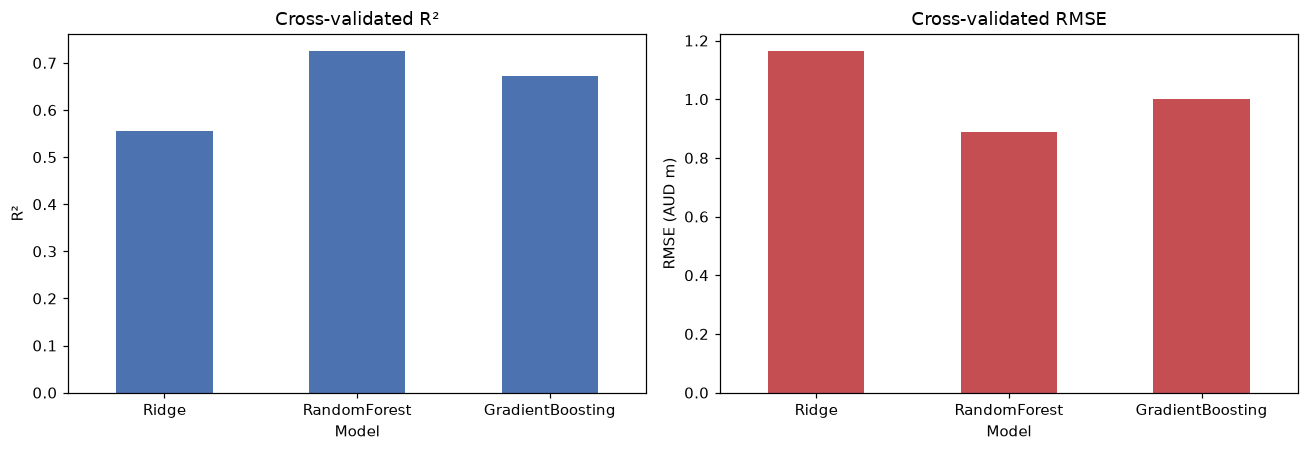

Best model by CV R²: RandomForest


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
results["CV R2"].plot.bar(ax=axes[0], color="#4C72B0"); axes[0].set(title="Cross-validated R²", ylabel="R²"); axes[0].tick_params(axis="x", rotation=0)
results["CV RMSE"].div(1e6).plot.bar(ax=axes[1], color="#C44E52"); axes[1].set(title="Cross-validated RMSE", ylabel="RMSE (AUD m)"); axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout(); fig.savefig(FIG_DIR / "model_comparison.png", bbox_inches="tight"); plt.show()
best_name = results["CV R2"].idxmax()
print("Best model by CV R²:", best_name)

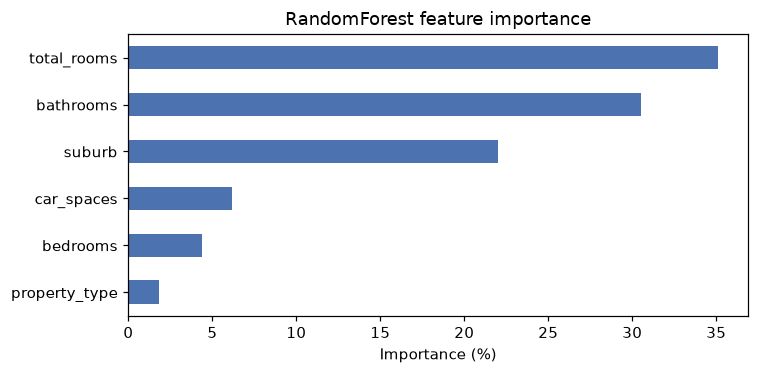

total_rooms      35.1%
bathrooms        30.5%
suburb           22.0%
car_spaces        6.2%
bedrooms          4.4%
property_type     1.8%
dtype: str


In [10]:
imp_pipe = pipes[best_name].fit(X_dev, y_dev)
names = imp_pipe.named_steps["prep"].get_feature_names_out()
imp = imp_pipe.named_steps["model"].feature_importances_

agg = {}
for n, v in zip(names, imp):
    base = n.split("__")[1]
    if base.startswith("suburb_"):        base = "suburb"
    elif base.startswith("property_type_"): base = "property_type"
    agg[base] = agg.get(base, 0) + v
imp_s = pd.Series(agg).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
(imp_s * 100).plot.barh(ax=ax, color="#4C72B0")
ax.invert_yaxis(); ax.set(title=f"{best_name} feature importance", xlabel="Importance (%)")
fig.tight_layout(); fig.savefig(FIG_DIR / "feature_importance.png", bbox_inches="tight"); plt.show()
print((imp_s * 100).round(1).astype(str) + "%")

Revisiting my feature expectations. Before modelling I expected suburb, bedrooms and bathrooms to matter most. The Random Forest importances partly support this: bathrooms (30%) and suburb (22%) are both in the top three, but bedrooms was not, on its own it contributes only about 4%. Instead, the engineered total-rooms feature (35%) is the strongest predictor. This suggests that overall property size, captured by combined room count, carries more signal than the bedroom count alone, and that a single bathroom figure is a better quality/scale proxy than I anticipated.

**Underfitting, overfitting and model recommendation**

Random Forest performed best, with a cross-validation R² of 0.72, RMSE of approximately $889,000 and MAE of $403,000. This supports my prediction that Random Forest would outperform the other models.

Both tree ensembles showed signs of overfitting. Random Forest's training R² was 0.95, compared with 0.72 in cross-validation. Gradient Boosting had an even larger gap, falling from approximately 1.00 during training to 0.67 in cross-validation. This suggests that it fitted the training properties very closely but generalised less successfully.

Ridge Regression achieved a training R² of 0.66 and cross-validation R² of 0.56. Its smaller gap suggests less overfitting, while its weaker performance on both sets is consistent with underfitting. Its linear structure may not capture the interactions between location and property characteristics.

I recommend Random Forest because it achieved the strongest cross-validation results across all three metrics. However, the substantial errors mean it should support an agent's appraisal rather than replace it. Ridge remains worth considering when interpretability is a priority, although these results do not establish that it is more stable. With only 92 development properties, additional data and validation would be needed before deployment. A further limitation is that standard k-fold cross-validation can place separate units from the same building into both training and validation folds (16 of the 102 records share a building address), which may make the cross-validated scores slightly optimistic; a grouped split by building would be a more conservative approach.

## Part 4 : Investigating Prediction Failures

Using out-of-fold predictions on the development set (every row predicted by a model that didn't see it), I isolate the five largest absolute errors.

In [11]:
best_pipe = pipes[best_name]
oof = cross_val_predict(best_pipe, X_dev, y_dev, cv=kf)

err = dev[["address","suburb","property_type","bedrooms","bathrooms","car_spaces"]].copy()
err["actual"] = y_dev.values
err["predicted"] = np.round(oof, -3)
err["error"] = err["predicted"] - err["actual"]
err["abs_error"] = err["error"].abs()
err["pct_error"] = (err["error"] / err["actual"] * 100).round(1)

print(f"OOF performance — MAE {mean_absolute_error(y_dev, oof):,.0f} | "
      f"RMSE {mean_squared_error(y_dev, oof)**0.5:,.0f} | R² {r2_score(y_dev, oof):.3f}")
worst5 = err.sort_values("abs_error", ascending=False).head(5)
worst5.to_csv(FIG_DIR / "largest_errors.csv", index=False)
worst5

OOF performance — MAE 402,761 | RMSE 928,218 | R² 0.756


,address,suburb,property_type,bedrooms,bathrooms,car_spaces,actual,predicted,error,abs_error,pct_error
76,21 Morella Road,Mosman,House,4,4,2.00,11650000,"6,584,000.00","-5,066,000.00","5,066,000.00",-43.50
73,3 Gordon Street,Mosman,House,5,2,2.00,7650000,"3,576,000.00","-4,074,000.00","4,074,000.00",-53.30
20,13 Lancaster Street,Blacktown,House,7,4,6.00,1900000,"5,111,000.00","3,211,000.00","3,211,000.00",169.00
93,105 Holt Avenue,Mosman,House,4,3,NaN,3550000,"6,094,000.00","2,544,000.00","2,544,000.00",71.70
101,5 Botanic Road,Mosman,House,4,3,2.00,8700000,"6,452,000.00","-2,248,000.00","2,248,000.00",-25.80


**Analysis of the five largest prediction errors**

1. **21 Morella Road, Mosman:** This four-bedroom, four-bathroom house with two car spaces sold for **$11.65 million**, but the model predicted **$6.584 million**. It under-predicted by **$5.066 million (43.5%)**. Unrecorded features such as views, condition or a premium position could help explain the difference. The limited number of expensive properties also makes this end of the market difficult to learn.

2. **3 Gordon Street, Mosman:** This five-bedroom, two-bathroom house with two car spaces sold for **$7.65 million**, compared with a prediction of **$3.576 million**. The under-prediction was **$4.074 million (53.3%)**. Its room counts may not capture the property's overall quality or location within Mosman. Land size, renovation quality and views are possible missing influences.

3. **13 Lancaster Street, Blacktown:** This seven-bedroom, four-bathroom house with six car spaces sold for **$1.90 million**, but was predicted at **$5.111 million**. The model over-predicted by **$3.211 million (169.0%)**. Its unusually large room and parking counts may have placed it alongside expensive houses in the model's decision rules. With few comparable Blacktown properties, the model may not have learned how these features interact with suburb.

4. **105 Holt Avenue, Mosman:** This four-bedroom, three-bathroom house had an actual price of **$3.55 million** and a predicted price of **$6.094 million**. The over-prediction was **$2.544 million (71.7%)**. Car spaces were missing and therefore imputed. Other unrecorded differences, such as condition, land size or position, could distinguish it from higher-priced houses with similar room counts.

5. **5 Botanic Road, Mosman:** This four-bedroom, three-bathroom house with two car spaces sold for **$8.70 million**, while the model predicted **$6.452 million**. It under-predicted by **$2.248 million (25.8%)**. The model could not account for potential architectural quality, renovations or a particularly desirable position, which may contribute value beyond the recorded features.

These explanations are plausible hypotheses rather than confirmed causes. All five errors involved houses, and four were in Mosman, suggesting difficulty with expensive or unusual properties. Predictions should therefore be treated cautiously for prestige homes and properties unlike the training sample. An agent should check the listing's condition, land, views and local context before relying on the estimate.

## Part 5 : Human Judgement vs Machine Learning vs LLM

The 10 pre-tagged **`holdout`** properties are the held-out test set. I compare three estimates against the true price:
1. **ML** : best model (trained on all development data) , filled below.
2. **LLM** : paste each property's details into ChatGPT, record its estimate.
3. **Human** : my own estimate.

In [12]:
final_dev = pipes[best_name].fit(X_dev, y_dev)
holdout = holdout.copy()
holdout["ml_estimate"] = np.round(final_dev.predict(holdout[FEATURES]), -3)

part5 = holdout[["address","suburb","property_type","bedrooms","bathrooms",
                 "car_spaces","sale_price","ml_estimate"]].rename(columns={"sale_price":"actual"})
part5["llm_estimate"] = np.nan     # <- fill after querying an LLM
part5["human_estimate"] = np.nan   # <- fill with your own estimate
part5 = part5.reset_index(drop=True)
part5.to_csv(FIG_DIR / "part5_comparison_blank.csv", index=False)
print("Saved figures/part5_comparison_blank.csv — fill the two estimate columns, then re-run the scoring cell.")
part5

Saved figures/part5_comparison_blank.csv — fill the two estimate columns, then re-run the scoring cell.


,address,suburb,property_type,bedrooms,bathrooms,car_spaces,actual,ml_estimate,llm_estimate,human_estimate
0,42 Burke Street,Blacktown,House,5,3,6.00,1260000,"1,992,000.00",NaN,NaN
1,41 Dagmar Crescent,Blacktown,House,3,1,2.00,880000,"1,203,000.00",NaN,NaN
2,45 & 45a Dina Beth Avenue,Blacktown,House,5,2,4.00,1250000,"1,359,000.00",NaN,NaN
3,10/4 Peace Lane,Parramatta,Apartment,2,2,1.00,570000,"640,000.00",NaN,NaN
4,5/30-32 Queens Avenue,Parramatta,Apartment,2,1,1.00,680000,"565,000.00",NaN,NaN
5,1417/32 Hunter Street (AKA 1417/45 Macquarie St),Parramatta,Apartment,1,1,1.00,560000,"467,000.00",NaN,NaN
6,2/81A Glover Street,Mosman,Apartment,2,2,1.00,1440000,"1,720,000.00",NaN,NaN
7,16/5 The Esplanade,Mosman,Apartment,1,1,1.00,1570000,"796,000.00",NaN,NaN
8,14 Almora Street,Mosman,House,3,3,2.00,5025000,"5,636,000.00",NaN,NaN
9,11 Euryalus Street,Mosman,House,6,4,3.00,7260000,"7,705,000.00",NaN,NaN


In [13]:
FILLED = Path("figures/part5_comparison_filled.csv")
if FILLED.exists():
    p5 = pd.read_csv(FILLED)
    for col in ["ml_estimate", "llm_estimate", "human_estimate"]:
        mae = (p5[col]-p5["actual"]).abs().mean()
        mape = ((p5[col]-p5["actual"]).abs()/p5["actual"]).mean()*100
        print(f"{col:15s}  MAE {mae:>12,.0f}   MAPE {mape:5.1f}%")


ml_estimate      MAE      355,200   MAPE  23.6%
llm_estimate     MAE      374,500   MAPE  18.0%
human_estimate   MAE      112,500   MAPE   6.9%


**Comparison of human, machine learning and LLM estimates**

The human estimates were closest on all ten properties, with an MAE of **$112,500** and MAPE of **6.9%**. Random Forest achieved an MAE of **$355,200**, compared with **$374,500** for the LLM. However, the LLM had a lower MAPE: **18.0%**, compared with **23.6%** for Random Forest. Therefore, the ML model performed better in average dollar terms, while the LLM performed better in average percentage terms.

Their strengths varied between properties. Random Forest was closer on **10/4 Peace Lane, Parramatta**, predicting $640,000 against an actual price of $570,000; the LLM estimated $750,000. Conversely, the LLM was closer on **5/30–32 Queens Avenue**, estimating $650,000 against $680,000, while Random Forest predicted $565,000. Random Forest was also closer on both expensive Mosman houses, although both approaches over-valued or under-valued individual properties.

Both automated approaches substantially under-valued **16/5 The Esplanade, Mosman**. It sold for $1.57 million, but Random Forest predicted $796,000 and the LLM estimated $950,000. This illustrates how suburb and room counts can leave important differences between properties unexplained.

The comparison has two important limitations. My human estimates were made with the actual prices visible, so their apparent advantage cannot demonstrate superior unaided judgement. The LLM estimates were also obtained in an existing conversation where the dataset had already been discussed, so they cannot be treated as a fully independent blind test.

My view is that informed human judgement still adds value by considering condition, views, land and local context that the model does not capture. Automated estimates can provide a starting point, but unusual or expensive properties need closer assessment. A stronger experiment would use new properties, record human estimates before revealing prices, and obtain LLM estimates in a fresh conversation containing only the permitted features.

## Part 6 : Deployment & Reflection

The final model is refit on all 102 rows and saved for the Streamlit app (`app.py`).

In [14]:
X_all, y_all = df[FEATURES], df[TARGET]
final_pipe = pipes[best_name].fit(X_all, y_all)
artifact = {"pipeline": final_pipe, "numeric": NUMERIC, "categorical": CATEGORICAL,
            "suburbs": sorted(df["suburb"].unique().tolist()),
            "property_types": sorted(df["property_type"].unique().tolist()),
            "model_name": best_name}
joblib.dump(artifact, MODEL_DIR / "housing_model.joblib")
print("Saved model/housing_model.joblib  (model:", best_name, ")")

Saved model/housing_model.joblib  (model: RandomForest )


**Reflection**

This project showed me that the information available about a property can matter as much as the model used to predict its price. Collecting records from public sold listings involves inconsistent formats, missing fields and the risk of transcription errors. Land size, floor area and build year were not consistently available, so they were excluded from the modelling dataset. This simplified preprocessing but removed potentially useful explanations for price differences, leaving the models dependent on suburb, property type and room counts.

Random Forest achieved the strongest cross-validation results, with an R² of approximately **0.72** and MAE of **$403,000**. Its ability to capture non-linear relationships and feature interactions may explain its advantage over Ridge. However, its higher training performance indicated overfitting, and the large prediction errors limited its practical usefulness. Building the Streamlit app made deployment straightforward, but making a prediction easy to access does not make it reliable. The app should provide a starting estimate for an agent to review. Its displayed ±15% range is illustrative rather than a validated prediction interval.

There are also ethical concerns. Suburb-based predictions can reproduce existing differences between locations, while an unrepresentative sample may produce uneven accuracy across property groups. Users could mistake an automated estimate for an objective valuation. Clear limitations, monitoring of errors across suburbs and property types, and human review are therefore important.

With more time, I would collect additional properties across more Sydney suburbs and a wider sale period. I would also prioritise condition, land and floor area, and finer location features. Listing descriptions could be explored through natural language processing, while photographs might provide condition information through computer vision. Finally, I would repeat the human and LLM comparison under properly blinded conditions.

